# Introduction (updated to match current analysis)

This notebook takes gene level summary statistics for OCD in humans and CD in dogs, performs network colocalization and defines a cross-species conserved CD network. The significance of this colocalization is assessed via comparison to an empirical null distribution and analysis of positive and negative control traits.  Analysis of the conserved CD network can be found in Notebook 2. 



# Set Up

In [ ]:
# Import required libraries
import os
import sys
import ndex2
from getpass import getpass
import pandas as pd
import mygene
mg = mygene.MyGeneInfo()
from netcoloc import netprop_zscore, netprop
import matplotlib.pyplot as plt
import seaborn as sns
#from matplotlib_venn import venn2, venn3

In [2]:
# Set up directory paths. Defaults to the Data/ and Figures/ folders within the repository.
cwd = os.path.dirname(os.getcwd())
DATADIR = os.path.join(cwd, "Data/")
FIGDIR = os.path.join(cwd, "Figures/rerun_")

In [3]:
# Import functions specific to this study
sys.path.append(cwd)
from updated_netcoloc_functions import *
from analysis_functions import *
from plotting_functions import *

# Load Input Data for dogCD and OCD

Seed gene sets are loaded 


## 1. Load molecular interaction network

Note: if you receive a connection error, please try again

In [4]:
pc_nodes, G_PC = load_pcnet()

#OBS make this change in the script: analysis_functions.py to the PCNet2.0
#interactome_uuid='d73d6357-e87b-11ee-9621-005056ae23aa' # for PCNet2.0 
# 
# Number of nodes: 19267 / Number of edges: 3852119

number of nodes:
19267

number of edges:
3852119


## 2. Load human and dog seed genes

In [5]:
# Set up directory paths. Defaults to the Data/ and Figures/ folders within the repository. 
# #i.e. /proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/CrossSpeciesBMI
cwd = os.path.dirname(os.getcwd())
DATADIR = os.path.join(cwd, "Data/")
FIGDIR = os.path.join(cwd, "Figures/")

In [6]:
#KT###  upload my NPS-scores:
#gene_dog_human_comb-zscores_250128.txt - with the header: gene, NPS_r, NPS_h, NPS_hr (h = human, r = dog, hr = dog-human)

nps_df = pd.read_csv(DATADIR + "outputs/ocd_ccd_zcomb_z12_251022.txt", sep = "\t", index_col=0) 
nps_df.head()

,NPS_r,NPS_h,NPS_hr
gene,,,
TGFBR1,2.074439,0.286812,0.594974
TGFBR2,1.872690,-0.609285,-1.141002
SMAD3,1.040744,0.070344,0.073211
TGFB1,-0.019932,-0.318449,0.006347
SMAD2,1.073654,-0.977044,-1.049007


In [7]:
## Load the final seed gene lists

#I also need the info from seed genes:
# load human seed genes
seed_bin_human_BMI = pd.read_csv('/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/NetColoc/data/OCDgenes_v4.txt')
print("Number of human BMI seeds:", len(seed_bin_human_BMI))

#remove genes not found in PCNet:
seed_bin_human_BMI = seed_bin_human_BMI[seed_bin_human_BMI['gene'].isin(nps_df.index)]
print("Number of human BMI seeds:", len(seed_bin_human_BMI))

# load dog seed genes
seed_bin_rat_BMI = pd.read_csv('/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/NetColoc/data/CCDgenes_Oct25.txt')
print("Number of rat BMI seeds:", len(seed_bin_rat_BMI))
#remove genes not found in PCNet:
seed_bin_rat_BMI = seed_bin_rat_BMI[seed_bin_rat_BMI['gene'].isin(nps_df.index)]
print("Number of rat BMI seeds:", len(seed_bin_rat_BMI))

Number of human BMI seeds: 48
Number of human BMI seeds: 48
Number of rat BMI seeds: 83
Number of rat BMI seeds: 82


In [8]:
# # Initialize dictionary for storing the seed genes
seed_dict = {'hBMI': seed_bin_human_BMI, 'rBMI': seed_bin_rat_BMI}

# 3. Perform Compulsive network colocalization

In [9]:
# set the number of repetitions for determining the null distribution at each node
num_reps = 10000

##### Precalculate network propagation heats - do this once or load the excisting one.

In [18]:
# precalculate network propagation heats - do this once!!!!!!
#w_prime = netprop.get_normalized_adjacency_matrix(G_PC, conserve_heat=True, weighted=False)
#indiv_heats = netprop.get_individual_heats_matrix(w_prime, alpha=0.5)

#np.save('w_prime_OCDv4_CCDsept25.npy', w_prime)
#np.save('indiv_heats_OCDv4_CCDsept25.npy', indiv_heats)

In [10]:
#load the above
w_prime = np.load('w_prime_OCDv4_CCDsept25.npy')
indiv_heats = np.load('indiv_heats_OCDv4_CCDsept25.npy')

## 4. Create a dictionary for Z-scores

In [11]:
# Initialize dictionary for storing z-scores
z_dict = {}

In [12]:
#build the dict:
z_dict['rBMI']=nps_df[["NPS_r"]].rename(columns={"NPS_r":"z"})
z_dict['hBMI']=nps_df[["NPS_h"]].rename(columns={"NPS_h":"z"})

## 5. Permutation Analysis of Mean NPS Score

In [13]:
has_nan = z_dict['hBMI'].isnull().values.any()
print("Any NaN values present:", has_nan)
nan_count = z_dict['rBMI'].isnull().sum()
print("Number of NaNs:", nan_count)


Any NaN values present: True
Number of NaNs: z    2
dtype: int64


In [14]:
#remove the 2 NaN values - obs modifies the original:
z_dict['rBMI'].dropna(inplace=True)


In [15]:
#remove the 2 NaN values - obs modifies the original:
z_dict['hBMI'].dropna(inplace=True)


## 6. Identify conserved network

In [18]:
# compile z scores and seed gene status for each gene in the network
netcoloc_data = pd.DataFrame(z_dict['hBMI']).join(z_dict['rBMI'], lsuffix="_human", rsuffix="_rat")

# identify the conserved network genes
#KT: my cutoffs:
conserved_network_genes = netcoloc_data[(netcoloc_data.z_human > 1.5) & (netcoloc_data.z_rat > 1.5) & (netcoloc_data.z_human * netcoloc_data.z_rat > 3)].index.values

## Uncomment to export the conserved network to file - done once
G_conserved = G_PC.subgraph(conserved_network_genes)
#nx.to_pandas_edgelist(G_conserved).to_csv(DATADIR + "outputs/Compulsive_conserved_network_edgelist_251022.tsv", sep="\t")
# look at file: head ../Data/outputs/Compulsive_conserved_network_edgelist_251022.tsv


## 8. Permutation Analysis of Conserved Network size

In [28]:
# Generate a null distribution of colocalized network size by shuffling the z_scores and applying the thresholds:
# KT thresholds: NPS_r > 3, NPS_h > 1.5, NPS_hr > 1.5

observed_BMI_sz, permuted_BMI_sz = calculate_expected_overlap(z_dict['rBMI'], z_dict['hBMI'], 
                                                            z_score_threshold=3, z1_threshold=1.5,
                                                            z2_threshold=1.5, num_reps=10000, plot=False, 
                                                            overlap_control="bin",
                                                            seed1=seed_dict['rBMI']['gene'].tolist(), seed2=seed_dict['hBMI']['gene'].tolist())

Overlap seed genes: 0


100%|██████████| 10000/10000 [06:59<00:00, 23.82it/s]


### Figure 1g

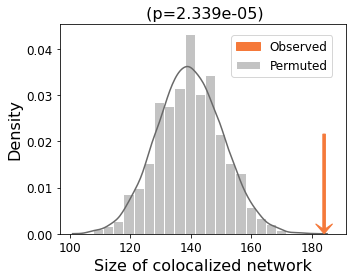

In [29]:
plot_permutation_histogram(permuted_BMI_sz, observed_BMI_sz,'', 'Size of colocalized network', color="dimgrey",arrow_color="#F5793A")

plt.tight_layout()                     # adjust to fit text
plt.savefig("/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/CrossSpeciesBMI/Data/PLOTS/OCD_CCD_netcoloc_size_histogram.pdf") 

# Control analysis

## Load control trait seed genes

### Reload my OCD & CCD seed genes as lists:

In [31]:
# # Initialize dictionary for storing the seed genes
z_dict = {}

In [32]:
# # Initialize dictionary for storing the seed genes
seed_dict = {}

In [33]:
#also read in the ocd and ccd z-scores again:

z_human_bin_OCD = pd.read_csv('/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/z_D1_OCD_z-scores_pcnet2_251022.csv', 
                              sep =",", index_col='gene',names=['gene','z'], header=0)
z_dict['hOCD'] = z_human_bin_OCD

z_dog_bin_CCD= pd.read_csv('/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/z_D2_CCD_Oct25_z-scores_pcnet2_251022.csv', 
                              sep =",", index_col='gene',names=['gene','z'], header=0)
z_dict['dCCD'] = z_dog_bin_CCD

In [34]:
#Load my OCD and dogCD seed genes as lists:
# load human seed genes: 
seed_bin_human_OCD = pd.read_csv('/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/NetColoc/data/OCDgenes_v4_noheader.txt',
                               sep="\t", header=None)[0].tolist() # Human OCD genes that exist in PCNet2.0 (all human seeds)

# load dog seed genes 
#cp /proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/NetColoc/data/CCDgenes_Oct25.txt /proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/NetColoc/data/CCDgenes_Oct25_inPCNet2.0_noheader.txt
seed_bin_dog_CCD = pd.read_csv('/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/NetColoc/data/CCDgenes_Oct25_inPCNet2.0_noheader.txt',
                               sep="\t", header=None)[0].tolist() # Dog CCD genes that exist in PCNet2.0

print("Number of OCD seeds:", len(seed_bin_human_OCD))
print("Number of CCD seeds:", len(seed_bin_dog_CCD))

seed_dict['hOCD'] = seed_bin_human_OCD
seed_dict['dCCD'] = seed_bin_dog_CCD

Number of OCD seeds: 48
Number of CCD seeds: 83


### Datasets for comparisons

## Control datasets from OCD correlation (Strom et al 2023)

### Negative controls: height (n=614), rheumatoid arthritis (n=118), type2 diabetes

### Positive control: depression (n=269) & Schizophrenia (n=477)

#### 1. Human height:

In [39]:
##Human height2
seed_bin_human_height2 = pd.read_csv(DATADIR+'inputs/controls/human_height2_seed_genes.txt',
                               sep="\t", header=None)[0].tolist() #no header at all in this file

print("Number of height seeds:", len(seed_bin_human_height2))

seed_dict['hHeight2'] = seed_bin_human_height2

Number of height seeds: 614


In [40]:
##### Control sets human height2
#z_human_height2 = netprop_zscore.calculate_heat_zscores(indiv_heats, list(G_PC.nodes),
#                                                    dict(G_PC.degree), 
#                                                    seed_bin_human_height2,
#                                                    num_reps=num_reps, alpha=0.5,
#                                                    minimum_bin_size=10,
#                                                    random_seed=1)
#pd.DataFrame(z_human_height2[0], columns=["z"]).to_csv(DATADIR+"outputs/controls/z_human_height2.tsv", sep="\t", index=True)
#z_dict['hHeight2'] = pd.DataFrame(z_human_height2[0], columns=["z"])


####next time use pre-calculated scores:
z_human_height2=pd.read_csv(DATADIR+'outputs/controls/z_human_height2.tsv',sep='\t', index_col='gene', names=['gene', 'z'], header=0)
z_dict['hHeight2'] = z_human_height2

#### 3. Human RA

In [43]:
##Human Reumathoid arthritis RA
seed_bin_human_RA = pd.read_csv(DATADIR+'inputs/controls/human_RA_seed_genes.txt',
                               sep="\t", header=None)[0].tolist() #no header at all in this file

print("Number of reumathoid arthritis seeds:", len(seed_bin_human_RA))

seed_dict['hRA'] = seed_bin_human_RA

Number of reumathoid arthritis seeds: 118


In [44]:
#### Control sets Reumathoid arthritis RA
#z_human_RA = netprop_zscore.calculate_heat_zscores(indiv_heats, list(G_PC.nodes),
#                                                    dict(G_PC.degree), 
#                                                    seed_bin_human_RA,
#                                                    num_reps=num_reps, alpha=0.5,
#                                                    minimum_bin_size=10,
#                                                    random_seed=1)
#pd.DataFrame(z_human_RA[0], columns=["z"]).to_csv(DATADIR+"outputs/controls/z_human_RA.tsv", sep="\t", index=True)
#z_dict['hRA'] = pd.DataFrame(z_human_RA[0], columns=["z"])

####next time use pre-calculated scores:
z_human_RA=pd.read_csv(DATADIR+'outputs/controls/z_human_RA.tsv',sep='\t', index_col='gene', names=['gene', 'z'], header=0)
z_dict['hRA'] = z_human_RA

#### 4. Human Depression (positive control)

In [45]:
##Positive control Human Depression
seed_bin_human_DEP = pd.read_csv(DATADIR+'inputs/controls/human_DEP_noMHC_seed_genes.txt',
                               sep="\t", header=None)[0].tolist() #no header at all in this file #list with Depression genes incl. MHC: human_DEP_seed_genes.txt

print("Number of depression seeds:", len(seed_bin_human_DEP))

seed_dict['hDEP'] = seed_bin_human_DEP

Number of depression seeds: 258


In [46]:
#### Positive control Depression
#z_human_DEP = netprop_zscore.calculate_heat_zscores(indiv_heats, list(G_PC.nodes),
#                                                    dict(G_PC.degree), 
#                                                    seed_bin_human_DEP,
#                                                    num_reps=num_reps, alpha=0.5,
#                                                    minimum_bin_size=10,
#                                                    random_seed=1)
#pd.DataFrame(z_human_DEP[0], columns=["z"]).to_csv(DATADIR+"outputs/controls/z_human_DEP_noMHC.tsv", sep="\t", index=True)
#z_dict['hDEP'] = pd.DataFrame(z_human_DEP[0], columns=["z"])

####next time use pre-calculated scores:
z_human_DEP=pd.read_csv(DATADIR+'outputs/controls/z_human_DEP_noMHC.tsv',sep='\t', index_col='gene', names=['gene', 'z'], header=0)
z_dict['hDEP'] = z_human_DEP

#### 5. Human schizophrenia 

In [47]:
##Positive control Human Schizophrenia
seed_bin_human_SCH = pd.read_csv(DATADIR+'inputs/controls/human_schiz_seed_genes.txt',
                               sep="\t", header=None)[0].tolist() #no header at all in this file 

print("Number of schizophrenia seeds:", len(seed_bin_human_SCH))

seed_dict['hSCH'] = seed_bin_human_SCH

Number of schizophrenia seeds: 477


In [48]:
#### Positive control Schizophrenia
#z_human_SCH = netprop_zscore.calculate_heat_zscores(indiv_heats, list(G_PC.nodes),
#                                                    dict(G_PC.degree), 
#                                                    seed_bin_human_SCH,
#                                                    num_reps=num_reps, alpha=0.5,
#                                                    minimum_bin_size=10,
#                                                    random_seed=1)
#pd.DataFrame(z_human_SCH[0], columns=["z"]).to_csv(DATADIR+"outputs/controls/z_human_SCH.tsv", sep="\t", index=True)
#z_dict['hSCH'] = pd.DataFrame(z_human_SCH[0], columns=["z"])

####next time use pre-calculated scores:
z_human_SCH=pd.read_csv(DATADIR+'outputs/controls/z_human_SCH.tsv',sep='\t', index_col='gene', names=['gene', 'z'], header=0)
z_dict['hSCH'] = z_human_SCH

#### 7. Type2 diabetes

In [53]:
##Positive control Human Age at menopause
seed_bin_human_DIA = pd.read_csv(DATADIR+'inputs/controls/human_type2diabetes_seed_genes.txt',
                               sep="\t", header=None)[0].tolist() #no header at all in this file 

print("Number of type2diabetes seeds:", len(seed_bin_human_DIA))

seed_dict['hDIA'] = seed_bin_human_DIA

Number of type2diabetes seeds: 70


In [54]:
##Negative control Human Age at menopause
#z_human_DIA = netprop_zscore.calculate_heat_zscores(indiv_heats, list(G_PC.nodes),
#                                                    dict(G_PC.degree), 
#                                                    seed_bin_human_DIA,
#                                                    num_reps=num_reps, alpha=0.5,
#                                                    minimum_bin_size=10,
#                                                    random_seed=1)
#pd.DataFrame(z_human_DIA[0], columns=["z"]).to_csv(DATADIR+"outputs/controls/z_human_DIA.tsv", sep="\t", index=True)
#z_dict['hDIA'] = pd.DataFrame(z_human_DIA[0], columns=["z"])

####next time use pre-calculated scores:
z_human_DIA=pd.read_csv(DATADIR+'outputs/controls/z_human_DIA.tsv',sep='\t', index_col='gene', names=['gene', 'z'], header=0)
z_dict['hDIA'] = z_human_DIA

## Dog control dataset - dog height

In [55]:
#DogHeight_seed_genes.txt - Q121_N-3276 dogs from Vista Feb 2025
##add my own genes just as a simple text file with genes in one column, no header:
seed_bin_dog_Height = pd.read_csv(DATADIR+'inputs/controls/DogHeight_seed_genes.txt', sep="\t", header=None)[0].tolist() #no header at all in this file

print("Number of Dog Height seeds:", len(seed_bin_dog_Height))
seed_dict['dHeight'] = seed_bin_dog_Height

Number of Dog Height seeds: 77


In [56]:
#DogHeight_seed_genes.txt - Q121_N-3276 dogs from Vista Feb 2025
# ##### 77 genes in network propagation
#z_dog_Height = netprop_zscore.calculate_heat_zscores(indiv_heats, list(G_PC.nodes),
#                                                    dict(G_PC.degree), 
#                                                    seed_bin_dog_Height,
#                                                    num_reps=num_reps, alpha=0.5,
#                                                    minimum_bin_size=10,
#                                                    random_seed=1)
#pd.DataFrame(z_dog_Height[0], columns=["z"]).to_csv(DATADIR+"outputs/controls/z_dog_Height.tsv", sep="\t", index=True)
#z_dict['dHeight'] = pd.DataFrame(z_dog_Height[0], columns=["z"])

####next time use pre-calculated scores:
z_dog_Height=pd.read_csv(DATADIR+'outputs/controls/z_dog_Height.tsv',sep='\t', index_col='gene', names=['gene', 'z'], header=0)
z_dict['dHeight'] = z_dog_Height

## Perform network colocalization of controls sets


In [57]:
#load my z-scores as a table to get the genes in PCNet2.0

nps_df = pd.read_csv(DATADIR + "outputs/ocd_ccd_zcomb_z12_251022.txt", sep = "\t", index_col=0)  # all dog are called rat
nps_df.head()


,NPS_r,NPS_h,NPS_hr
gene,,,
TGFBR1,2.074439,0.286812,0.594974
TGFBR2,1.872690,-0.609285,-1.141002
SMAD3,1.040744,0.070344,0.073211
TGFB1,-0.019932,-0.318449,0.006347
SMAD2,1.073654,-0.977044,-1.049007


In [ ]:
#remove genes not in PCNet
seed_bin_dog_CCD = [gene for gene in seed_bin_dog_CCD if gene in set(nps_df.index)]
print("Number of dog CCD seeds in PCNet:", len(seed_bin_dog_CCD))

seed_bin_human_OCD = [gene for gene in seed_bin_human_OCD if gene in set(nps_df.index)]
print("Number of human OCD seeds in PCNet:", len(seed_bin_human_OCD))

seed_bin_human_height2 = [gene for gene in seed_bin_human_height2 if gene in set(nps_df.index)]
print("Number of human height seeds in PCNet:", len(seed_bin_human_height2))

seed_bin_dog_Height = [gene for gene in seed_bin_dog_Height if gene in set(nps_df.index)]
print("Number of dog height seeds in PCNet:", len(seed_bin_dog_Height))

seed_bin_human_RA = [gene for gene in seed_bin_human_RA if gene in set(nps_df.index)]
print("Number of human RA seeds in PCNet:", len(seed_bin_human_RA))

seed_bin_human_DEP = [gene for gene in seed_bin_human_DEP if gene in set(nps_df.index)]
print("Number of human depression seeds in PCNet:", len(seed_bin_human_DEP))

seed_bin_human_SCH = [gene for gene in seed_bin_human_SCH if gene in set(nps_df.index)]
print("Number of human schizophrenia seeds in PCNet:", len(seed_bin_human_SCH))

seed_bin_human_DIA = [gene for gene in seed_bin_human_DIA if gene in set(nps_df.index)]
print("Number of human type2 diabetes seeds in PCNet:", len(seed_bin_human_DIA))

In [59]:
# # Initialize dictionary for storing the seed genes
seed_dict = {}

In [60]:
# KT modified: add control seed genes to the seed gene dictionary z_dict['hOCDrest'] = z_human_OCDrestricted
seed_dict = {'dCCD':seed_bin_dog_CCD,'hOCD': seed_bin_human_OCD,
             'hHeight2': seed_bin_human_height2, 'dHeight': seed_bin_dog_Height,
             'hRA':seed_bin_human_RA,'hDEP':seed_bin_human_DEP,'hSCH':seed_bin_human_SCH, 'hDIA':seed_bin_human_DIA,
              **seed_dict}

In [61]:
# Define the comparisons to be made
control_combinations = [ ('dCCD', 'hOCD'), 
                        ('hOCD', 'hDEP'),('dCCD', 'hDEP'),
                        ('hOCD', 'hSCH'),('dCCD', 'hSCH'),
                        ('dHeight','hHeight2'),
                        ('dCCD', 'hRA'),('hOCD', 'hRA'),   
                        ('dCCD', 'hHeight2'),('hOCD', 'hHeight2'),
                        ('dCCD', 'hDIA'),('hOCD', 'hDIA')
                        ] # 
                        

In [ ]:
control_analysis = []
# analyse all combinations
for combo in control_combinations:
    observed, permuted = calculate_expected_overlap(z_dict[combo[0]], z_dict[combo[1]], 
                                                    z_score_threshold=3, z1_threshold=1.5,
                                                    z2_threshold=1.5, num_reps=1000, plot=False, 
                                                    overlap_control="remove",
                                                    seed1=seed_dict[combo[0]], seed2=seed_dict[combo[1]])
    control_analysis.append(get_permutation_stats(observed, permuted, "-".join(combo)))

In [67]:
control_results = pd.concat(control_analysis)

In [ ]:
#control_results.to_csv(DATADIR+'outputs/controlanalyses_260521.csv', header=True, index=True, encoding='utf-8')
control_results = pd.read_csv(DATADIR + "outputs/controlanalyses_260521.csv", sep = ",", index_col=0) 
control_results.head(20)

## Plot results of control analysis

### Figure Control analyses

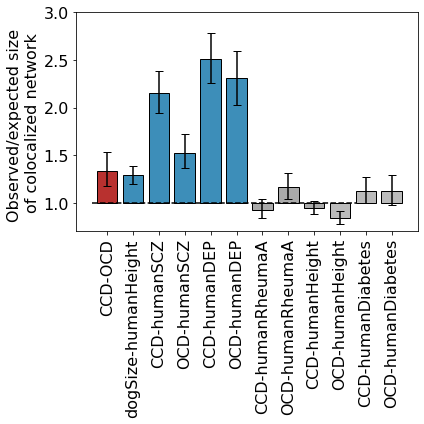

In [20]:
plt.figure(figsize=(6, 6))
main_fig = control_results.loc[['dCCD-hOCD','dHeight-hHeight2',
                                'dCCD-hSCH','hOCD-hSCH','dCCD-hDEP','hOCD-hDEP',
                                'dCCD-hRA','hOCD-hRA',
                                'dCCD-hHeight2','hOCD-hHeight2',
                                'dCCD-hDIA','hOCD-hDIA']] 
plt.bar(x = main_fig.index,
       bottom= 1, height = main_fig.Mean - 1, capsize=4, edgecolor="black",
        yerr = [main_fig.Mean - main_fig.Lower, main_fig.Upper - main_fig.Mean],
       color = ["#b8312f"]*1 + ["#3d8eb9"]*5 + ["#aaaaaa"]*3+ ["#bbbbbb"]*3 ) #+ 
plt.xticks(fontsize=16, rotation=90, ticks=main_fig.index, 
          labels = ['CCD-OCD' ,'dogSize-humanHeight',
                    'CCD-humanSCZ','OCD-humanSCZ','CCD-humanDEP','OCD-humanDEP',
                    'CCD-humanRheumaA','OCD-humanRheumaA',
                    'CCD-humanHeight', 'OCD-humanHeight', 
                    'CCD-humanDiabetes','OCD-humanDiabetes'])
plt.ylabel("Observed/expected size \nof colocalized network", fontsize=16)
plt.yticks(fontsize=16)
plt.hlines(y=1, xmin=-0.6, xmax=9.6, linestyle="dashed", color="black")
plt.ylim(0.7, 3.0)  # <- set y-axis to go up to 1.7
plt.tight_layout()                     # adjust to fit text

plt.savefig("/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/CrossSpeciesBMI/Data/PLOTS/control_analyses_CCD_figure4v2.pdf")      # or add bbox_inches="tight" if needed
